In [20]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.utils import plot_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [21]:
# =========================
# Parámetros
# =========================
DATASET_DIR = "dataset"
IMG_SIZE = (224, 224)
CHANNELS = 1
BATCH_SIZE = 32
SEED = 42
EPOCHS = 10

In [22]:
# Establecer la semilla
np.random.seed(SEED)

# Establecer la semilla para el generador de TensorFlow
tf.random.set_seed(SEED)

Distribución total por clase:
- glioma: 1621
- healthy: 2000
- meningioma: 1645
- pituitary: 1757


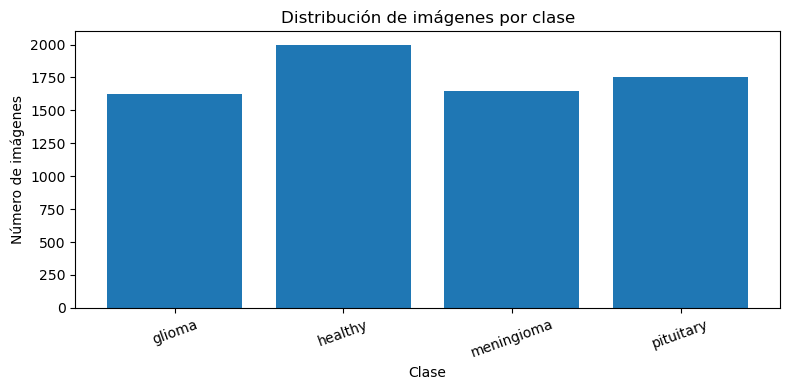

In [23]:
# =========================
# Distribución por clases
# =========================
class_counts = {}

for class_name in class_names:
    class_dir = os.path.join(DATASET_DIR, class_name)
    if os.path.isdir(class_dir):
        n_images = len([
            f for f in os.listdir(class_dir)
            if os.path.isfile(os.path.join(class_dir, f))
        ])
    else:
        n_images = 0
    class_counts[class_name] = n_images

print("Distribución total por clase:")
for class_name, count in class_counts.items():
    print(f"- {class_name}: {count}")

plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Distribución de imágenes por clase")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


In [25]:
# =========================
# Carga de datos
# =========================
def load_data() :
    # Carga de datos de entrenamiento
    train_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode = "grayscale",
    verbose = True
    )

    # Carga de datos de validación y prueba
    temp_ds = image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    color_mode = "grayscale",
    verbose = True
    )

    # Nombre de las clases
    class_names = train_ds.class_names

    # Separación validación / prueba
    temp_batches = tf.data.experimental.cardinality(temp_ds).numpy()
    val_size = temp_batches // 2

    val_ds = temp_ds.take(val_size)
    test_ds = temp_ds.skip(val_size)

    # Prefetch para rendimiento
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = train_ds.prefetch(AUTOTUNE)
    val_ds = val_ds.prefetch(AUTOTUNE)
    test_ds = test_ds.prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds, class_names

In [26]:
train_ds, val_ds, test_ds, class_names = load_data()
NUM_CLASSES = len(class_names)

Found 7023 files belonging to 4 classes.
Using 4917 files for training.
Found 7023 files belonging to 4 classes.
Using 2106 files for validation.


In [27]:
# =========================
# Verificación de tamaños
# =========================
train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
test_batches = tf.data.experimental.cardinality(test_ds).numpy()

print(f"Clases: {class_names}")
print(f"Batches de entrenamiento: {train_batches}")
print(f"Batches de validación: {val_batches}")
print(f"Batches de prueba: {test_batches}")
print(f"Steps por época esperados en entrenamiento: {train_batches}")
print(f"Imágenes aproximadas de entrenamiento: {train_batches * BATCH_SIZE}")
print(f"Steps por época esperados en validación: {val_batches}")
print(f"Imágenes aproximadas de validación: {val_batches * BATCH_SIZE}")
print(f"Steps por época esperados en prueba: {test_batches}")
print(f"Imágenes aproximadas de prueba: {test_batches * BATCH_SIZE}")

Clases: ['glioma', 'healthy', 'meningioma', 'pituitary']
Batches de entrenamiento: 154
Batches de validación: 33
Batches de prueba: 33
Steps por época esperados en entrenamiento: 154
Imágenes aproximadas de entrenamiento: 4928
Steps por época esperados en validación: 33
Imágenes aproximadas de validación: 1056
Steps por época esperados en prueba: 33
Imágenes aproximadas de prueba: 1056


In [28]:
# =============================
# Validación rápida de un batch
# =============================
for images, labels in train_ds.take(1):
    X_batch = images.numpy()
    y_batch = labels.numpy()

print("X_batch shape:", X_batch.shape)
print("y_batch shape:", y_batch.shape)
print("Primeras etiquetas:", y_batch[:10])

X_batch shape: (32, 224, 224, 1)
y_batch shape: (32, 4)
Primeras etiquetas: [[0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]


In [29]:
def load_model() :
    model = models.Sequential([
        layers.Input(shape=(224, 224, 1), name="Input"),
        layers.Rescaling(1./255, name="Rescaling"),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="Conv2D_1"),
        layers.MaxPooling2D(name="MaxPooling2D_1"),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="Conv2D_2"),
        layers.MaxPooling2D(name="MaxPooling2D_2"),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="Conv2D_3"),
        layers.MaxPooling2D(name="MaxPooling2D_3"),

        layers.Conv2D(256, (3, 3), activation='relu', padding='same', name="Conv2D_4"),
        layers.MaxPooling2D(name="MaxPooling2D_4"),

        layers.Flatten(name="Flatten"),
        layers.Dense(256, activation='relu', name="Dense_1"),
        layers.Dropout(0.5, name="Dropout"),
        layers.Dense(NUM_CLASSES, activation='softmax', name="Dense_Output")
    ], name="Modelo_CNN_MRI")
    return model


In [30]:
modelo = load_model()
modelo.summary()

Model: "Modelo_CNN_MRI"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Rescaling (Rescaling)           │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_1 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_1 (MaxPooling2D)   │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_2 (MaxPooling2D)   │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_3 (MaxPooling2D)   │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_4 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling2D_4 (MaxPooling2D)   │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Output (Dense)            │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,234,180 (50.48 MB)

 Trainable params: 13,234,180 (50.48 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
modelo.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy', 'Precision', 'Recall'])
history = modelo.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS
)

Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - Precision: 0.7781 - Recall: 0.5469 - accuracy: 0.6720 - loss: 0.7932 - val_Precision: 0.8269 - val_Recall: 0.7150 - val_accuracy: 0.7860 - val_loss: 0.5600
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 182s 1s/step - Precision: 0.8422 - Recall: 0.7936 - accuracy: 0.8192 - loss: 0.4547 - val_Precision: 0.8409 - val_Recall: 0.8059 - val_accuracy: 0.8229 - val_loss: 0.4608
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - Precision: 0.8823 - Recall: 0.8585 - accuracy: 0.8719 - loss: 0.3201 - val_Precision: 0.8448 - val_Recall: 0.8144 - val_accuracy: 0.8352 - val_loss: 0.3721
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - Precision: 0.9047 - Recall: 0.8942 - accuracy: 0.9005 - loss: 0.2524 - val_Precision: 0.9077 - val_Recall: 0.9034 - val_accuracy: 0.9053 - val_loss: 0.2688
Epoch 5/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - Precision: 0.9267 - Recall: 0.9203 - accuracy: 0.9233 - loss: 0.2020 - val_Precision: 0.9228 - val_Re

In [11]:
history.history.keys()

dict_keys(['Precision', 'Recall', 'accuracy', 'loss', 'val_Precision', 'val_Recall', 'val_accuracy', 'val_loss'])

In [ ]:
def visualization_history(resultsFit):
    # Llamado al entrono de la gráfica y fijar tamaño de visualización
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Graficar la precisión de la historia en entrenamiento
    axes[0].plot(range(len(resultsFit.history['accuracy'])), resultsFit.history['accuracy'],
           '#5a2ff4', linestyle = "-", marker = "o",
           label='Precisión entrenamiento', lw = 3)

    # Graficar la precisión de la historia en validación
    axes[0].plot(range(len(resultsFit.history['val_accuracy'])), resultsFit.history['val_accuracy'],  '#60d13e',
           label='Precisión validación', linestyle = '-', marker = 'o', lw = 3)

    # Títulos de los ejes
    axes[0].set_xlabel('Época',fontsize=16)
    axes[0].set_ylabel(r'Precisión',fontsize=16)
    axes[0].set_ylim(top=1) # Límite de la gráfica
    axes[0].grid()      # Activar la cuadrícula
    axes[0].legend(fontsize=14,loc = 'lower right')   # Establecer la leyenda


    # Graficar la pérdida de la historia en entrenamiento
    axes[1].plot(range(len(resultsFit.history['loss'])), resultsFit.history['loss'],
           '#5a2ff4', linestyle = "-", marker = "o",
           label='Pérdida entrenamiento', lw = 3)

    # Graficar la precisión de la historia en validación
    axes[1].plot(range(len(resultsFit.history['val_loss'])), resultsFit.history['val_loss'],  '#60d13e',
           label='Pérdida validación', linestyle = '-', marker = 'o', lw = 3)

    # Títulos de los ejes
    axes[1].set_xlabel('Época',fontsize=16)
    axes[1].set_ylabel(r'Pérdida',fontsize=16)
    axes[1].grid()      # Activar la cuadrícula
    axes[1].legend(fontsize=14,loc = 'upper right')   # Establecer la leyenda


    plt.tight_layout() # Ajusta automáticamente el diseño de la figura
    plt.show()

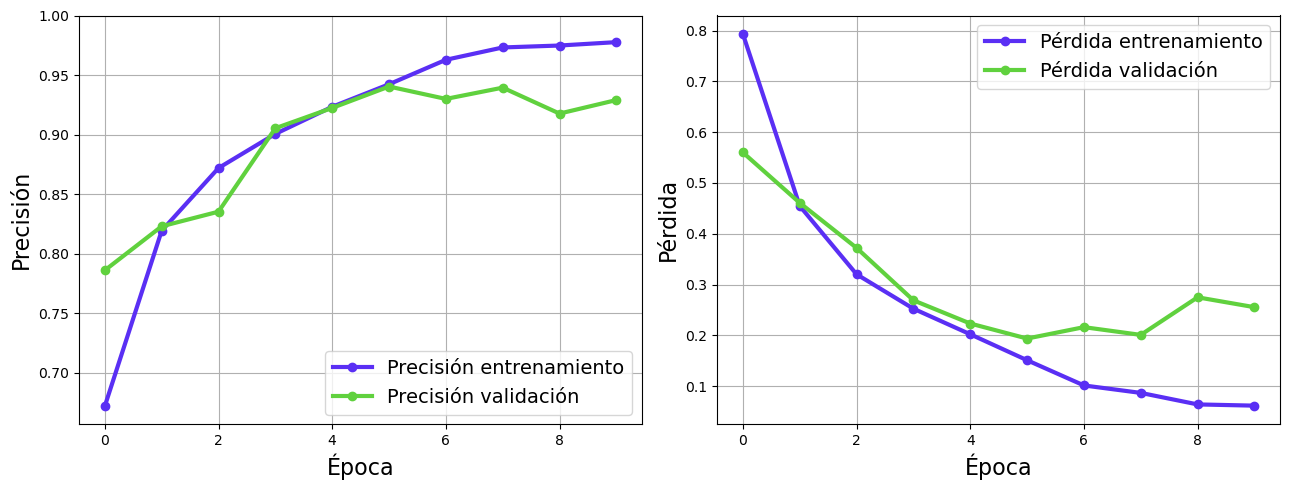

In [13]:
visualization_history(history)

In [17]:
# Evaluación del modelo en el conjunto de prueba
results = modelo.evaluate(test_ds)
print("Resultados en el conjunto de prueba:", results)

# Los resultados contendrán los valores de las métricas definidas, por ejemplo, pérdida y precisión.
print(f'Pérdida en el conjunto de prueba: {results[0]:0.2f}')
print(f'Precisión en el conjunto de prueba:{results[1]:0.2f}')

33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 209ms/step - Precision: 0.9305 - Recall: 0.9305 - accuracy: 0.9305 - loss: 0.2583
Resultados en el conjunto de prueba: [0.258256733417511, 0.930476188659668, 0.930476188659668, 0.930476188659668]
Pérdida en el conjunto de prueba: 0.26
Precisión en el conjunto de prueba:0.93
